In [1]:
from ultralytics import YOLOWorld

import torch
import cv2
import matplotlib.pyplot as plt

In [2]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)


cpu


In [31]:
model = YOLOWorld("models/yolov8s-world.pt")

In [4]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))
from datasets.visual_genome import VisualGenomeLoader

loader = VisualGenomeLoader("../datasets/visual_genome")

scene = loader.load_scene(0)

image = scene.image

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

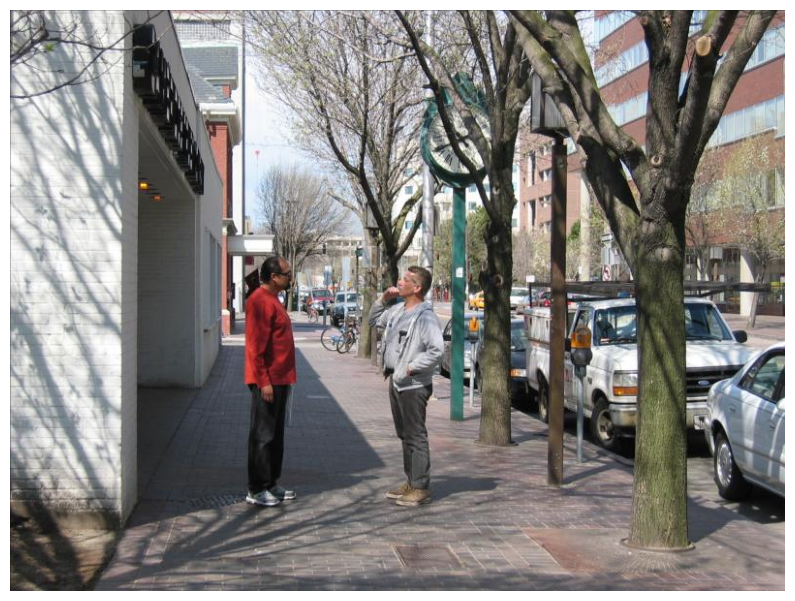

In [5]:
plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")

In [6]:
vg_classes = list(loader.dictionary["label_to_idx"].keys())

print(len(vg_classes))
print(vg_classes[:20])

150
['air', 'airplane', 'animal', 'arm', 'back', 'background', 'bag', 'banana', 'basket', 'beach', 'bear', 'bed', 'bench', 'bike', 'bird', 'board', 'boat', 'book', 'bottle', 'bowl']


In [7]:
vg_classes.remove("background")

print(len(vg_classes))

149


In [8]:
model.set_classes(vg_classes)

In [9]:
results = model.predict(
    image,
    conf=0.25,
    verbose=False
)

In [10]:
print(type(results))
print(len(results))
result = results[0]

print(type(result))
print(result)

<class 'list'>
1
<class 'ultralytics.engine.results.Results'>
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'air', 1: 'airplane', 2: 'animal', 3: 'arm', 4: 'back', 5: 'bag', 6: 'banana', 7: 'basket', 8: 'beach', 9: 'bear', 10: 'bed', 11: 'bench', 12: 'bike', 13: 'bird', 14: 'board', 15: 'boat', 16: 'book', 17: 'bottle', 18: 'bowl', 19: 'box', 20: 'boy', 21: 'branch', 22: 'building', 23: 'bus', 24: 'bush', 25: 'cabinet', 26: 'cake', 27: 'cap', 28: 'car', 29: 'cat', 30: 'ceiling', 31: 'chair', 32: 'child', 33: 'clock', 34: 'cloud', 35: 'coat', 36: 'container', 37: 'couch', 38: 'counter', 39: 'cow', 40: 'cup', 41: 'design', 42: 'desk', 43: 'dirt', 44: 'dish', 45: 'dog', 46: 'door', 47: 'ear', 48: 'elephant', 49: 'eye', 50: 'face', 51: 'fence', 52: 'field', 53: 'floor', 54: 'flower', 55: 'food', 56: 'foot', 57: 'fork', 58: 'frisbee', 59: 'giraffe', 60: 'girl', 61: 'glass', 62: 'g

In [11]:
boxes = result.boxes

print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 93.,  93.,  28.,  12., 140., 113., 115., 136., 136.])
conf: tensor([0.8132, 0.7704, 0.6459, 0.5637, 0.4357, 0.3719, 0.3004, 0.2656, 0.2549])
data: tensor([[3.7548e+02, 2.6303e+02, 4.4918e+02, 5.1211e+02, 8.1317e-01, 9.3000e+01],
        [2.3951e+02, 2.5329e+02, 2.9812e+02, 5.1420e+02, 7.7042e-01, 9.3000e+01],
        [7.1772e+02, 3.3940e+02, 8.0000e+02, 5.3185e+02, 6.4591e-01, 2.8000e+01],
        [3.2344e+02, 3.1655e+02, 3.6234e+02, 3.5520e+02, 5.6373e-01, 1.2000e+01],
        [5.3061e+02, 2.9043e+02, 7.7242e+02, 4.5896e+02, 4.3566e-01, 1.4000e+02],
        [3.9645e+02, 4.9217e+02, 4.3445e+02, 5.1247e+02, 3.7190e-01, 1.1300e+02],
        [4.5088e+01, 3.2813e+02, 7.9901e+02, 5.9993e+02, 3.0041e-01, 1.1500e+02],
        [1.9110e+02, 3.5820e-02, 7.9729e+02, 5.6278e+02, 2.6560e-01, 1.3600e+02],
        [4.6827e+02, 0.0000e+00, 7.9848e+02, 5.5666e+02, 2.5488e-01, 1.3600e+02]])
id: None
is_track: False
orig_shape: (600,

In [12]:
[attr for attr in dir(boxes) if not attr.startswith("_")]

['cls',
 'conf',
 'cpu',
 'cuda',
 'data',
 'id',
 'is_track',
 'numpy',
 'orig_shape',
 'shape',
 'to',
 'xywh',
 'xywhn',
 'xyxy',
 'xyxyn']

In [13]:
for cls in boxes.cls:
    print(int(cls), result.names[int(cls)])

93 person
93 person
28 car
12 bike
140 vehicle
113 shoe
115 sidewalk
136 tree
136 tree


In [14]:
for conf in boxes.conf:
    print(float(conf))

0.813167154788971
0.7704183459281921
0.6459053158760071
0.5637255907058716
0.43566280603408813
0.3719015419483185
0.3004133701324463
0.26560378074645996
0.25488460063934326


In [15]:
print(boxes.xywh)

tensor([[412.3297, 387.5708,  73.7059, 249.0735],
        [268.8121, 383.7471,  58.6105, 260.9142],
        [758.8586, 435.6240,  82.2827, 192.4459],
        [342.8892, 335.8777,  38.8989,  38.6472],
        [651.5144, 374.6914, 241.8133, 168.5274],
        [415.4515, 502.3210,  37.9970,  20.3033],
        [422.0488, 464.0299, 753.9213, 271.7992],
        [494.1936, 281.4059, 606.1887, 562.7402],
        [633.3768, 278.3279, 330.2052, 556.6558]])


In [16]:
from datasets.visual_genome.models import BoundingBox
from datasets.visual_genome.models import SceneObject
objects = []

for i in range(len(boxes)):
    box = boxes.xywh[i]
    cls = int(boxes.cls[i])
    conf = float(boxes.conf[i])
    bbox = BoundingBox(
    cx=float(box[0]),
    cy=float(box[1]),
    width=float(box[2]),
    height=float(box[3])
    )
    obj = SceneObject(
    object_index=i,                 # temporary
    label_index=cls,
    label=result.names[cls],
    bbox=bbox,
    confidence=conf
    )
    objects.append(obj)
print(len(objects))

9


In [17]:
for obj in objects:
    print(obj)

SceneObject(object_index=0, label_index=93, label='person', bbox=BoundingBox(cx=412.3297119140625, cy=387.5708312988281, width=73.70590209960938, height=249.07354736328125), confidence=0.813167154788971, attributes=[])
SceneObject(object_index=1, label_index=93, label='person', bbox=BoundingBox(cx=268.8121032714844, cy=383.7471008300781, width=58.6104736328125, height=260.91424560546875), confidence=0.7704183459281921, attributes=[])
SceneObject(object_index=2, label_index=28, label='car', bbox=BoundingBox(cx=758.858642578125, cy=435.62396240234375, width=82.28271484375, height=192.4459228515625), confidence=0.6459053158760071, attributes=[])
SceneObject(object_index=3, label_index=12, label='bike', bbox=BoundingBox(cx=342.88916015625, cy=335.8777160644531, width=38.89892578125, height=38.647216796875), confidence=0.5637255907058716, attributes=[])
SceneObject(object_index=4, label_index=140, label='vehicle', bbox=BoundingBox(cx=651.514404296875, cy=374.69140625, width=241.813293457031

In [18]:
from datasets.visual_genome.models import ImageInfo

image_info = ImageInfo(
    width=image.size[1],
    height=image.size[0]
)

In [20]:
from datasets.visual_genome.models import Scene

yolo_scene = Scene(
    image=image,
    info=image_info,
    objects=objects,
    relationships=[]
)

IMAGE INFORMATION
----------------------------------------------------------------------
Image Index : None
Image ID    : None
Resolution  : 600 × 800
Objects     : 9
Relations   : 0

OBJECTS
----------------------------------------------------------------------
[0] person
Bounding Box : (412.3297119140625, 387.5708312988281, 73.70590209960938, 249.07354736328125)

[1] person
Bounding Box : (268.8121032714844, 383.7471008300781, 58.6104736328125, 260.91424560546875)

[2] car
Bounding Box : (758.858642578125, 435.62396240234375, 82.28271484375, 192.4459228515625)

[3] bike
Bounding Box : (342.88916015625, 335.8777160644531, 38.89892578125, 38.647216796875)

[4] vehicle
Bounding Box : (651.514404296875, 374.69140625, 241.81329345703125, 168.52743530273438)


RELATIONSHIPS
----------------------------------------------------------------------


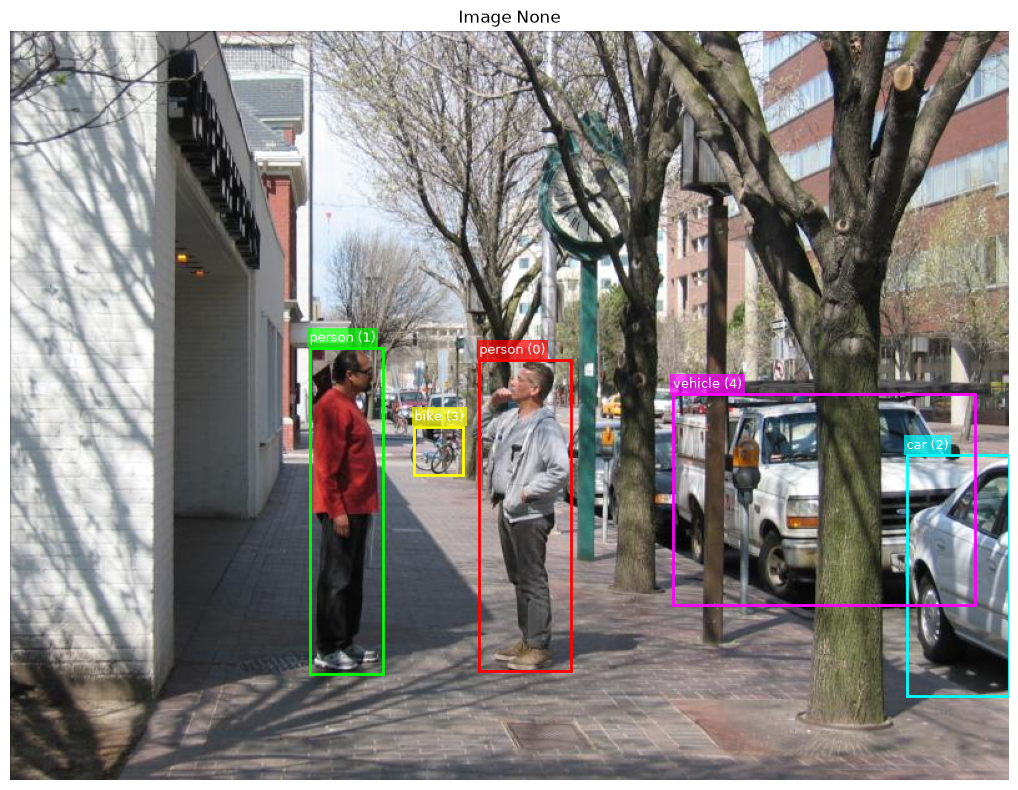

In [21]:
from datasets.visual_genome.visualisations import show_scene

show_scene(
    yolo_scene,
    num_objects=5,
    num_rels=0
)

In [ ]:
gt_scene = loader.load_scene(0)
gt_labels = {obj.label for obj in gt_scene.objects}

print("GROUND TRUTH")
print("-" * 40)

for label in sorted(gt_labels):
    print(label)

GROUND TRUTH
----------------------------------------
arm
back
bike
building
car
clock
jacket
pant
person
road
shirt
shoe
sidewalk
sign
street
tree
wall
window


In [25]:
from datasets.visual_genome import ImageInfo, Scene

image_info = ImageInfo(
    width=image.size[1],
    height=image.size[0]
)

yolo_scene = Scene(
    image=image,
    info=image_info,
    objects=objects,
    relationships=[]
)

In [26]:
print(len(gt_scene.objects))
print(len(yolo_scene.objects))

23
9


In [27]:
gt_labels = {obj.label for obj in gt_scene.objects}

print("GROUND TRUTH")
print("-" * 40)

for label in sorted(gt_labels):
    print(label)

GROUND TRUTH
----------------------------------------
arm
back
bike
building
car
clock
jacket
pant
person
road
shirt
shoe
sidewalk
sign
street
tree
wall
window


In [28]:
yolo_labels = {obj.label for obj in yolo_scene.objects}

print("YOLO")
print("-" * 40)

for label in sorted(yolo_labels):
    print(label)

YOLO
----------------------------------------
bike
car
person
shoe
sidewalk
tree
vehicle


In [29]:
common = gt_labels & yolo_labels
missing = gt_labels - yolo_labels
extra = yolo_labels - gt_labels

In [ ]:
print("COMMON OBJECTS")
print("-" * 60)

for obj in sorted(common):
    print(obj)
print()
print("MISSING OBJECTS")
print("-" * 60)

for obj in sorted(missing):
    print(obj)
print()
print("EXTRA OBJECTS")
print("-" * 60)

for obj in sorted(extra):
    print(obj)
print()
print("STATISTICS")
print("-" * 60)

print(f"GT Objects      : {len(gt_labels)}")
print(f"YOLO Objects    : {len(yolo_labels)}")
print(f"Common Objects  : {len(common)}")
print(f"Missing Objects : {len(missing)}")
print(f"Extra Objects   : {len(extra)}")

coverage = len(common) / len(gt_labels)

print(f"\nCoverage : {coverage:.2%}")

COMMON OBJECTS
bike
car
person
shoe
sidewalk
tree

MISSING OBJECTS
arm
back
building
clock
jacket
pant
road
shirt
sign
street
wall
window

EXTRA OBJECTS
vehicle

STATISTICS
GT Objects      : 18
YOLO Objects    : 7
Common Objects  : 6
Missing Objects : 12
Extra Objects   : 1

Coverage : 33.33%


## Conclusion

- Successfully integrated YOLO-World.
- Restricted detections to the Visual Genome vocabulary.
- Verified compatibility with the Scene SDK.
- Confirmed that YOLO detections can replace ground-truth objects during deployment.

Next:
Build the relationship training dataset from Visual Genome ground-truth annotations.